# Notebook 05 — Urban Environmental Relationships

**หัวข้อ:** Urban Environmental Relationships — จากแผนที่สู่แบบจำลองอย่างง่าย

**คำถามหลัก:** *Vegetation มีความสัมพันธ์เชิงพื้นที่กับ Land Surface Temperature หรือไม่?*

### วัตถุประสงค์การเรียนรู้
- แยก dependent และ independent variable
- สร้าง spatial sample จาก raster stack
- อ่าน scatterplot
- คำนวณ Pearson correlation
- สร้าง simple linear regression
- ตีความ slope, intercept และ $R^2$
- แยก **association** ออกจาก **causation**
- เข้าใจ spatial autocorrelation และ confounding ในระดับเบื้องต้น

## 1. Model ที่ใช้

เราเริ่มจากแบบจำลองง่ายที่สุด:

$$
LST_i = \beta_0 + \beta_1 NDVI_i + \epsilon_i
$$

โดย:
- $LST_i$ = dependent variable
- $NDVI_i$ = independent variable
- $\beta_0$ = intercept
- $\beta_1$ = slope

**เป้าหมายของคาบนี้คือวัดความสัมพันธ์ ไม่ใช่พิสูจน์ causation**

## 2. เหตุผลที่ใช้ NDVI และ LST จาก Landsat ชุดเดียวกัน

เพื่อให้ spatial resolution และช่วงเวลาของตัวแปรสอดคล้องกันมากขึ้น เราจะคำนวณ:
- NDVI จาก Landsat `SR_B5` และ `SR_B4`
- LST จาก Landsat `ST_B10`

จาก hot-season composite เดียวกัน

นี่เป็นตัวอย่างของหลักการ **temporal and spatial matching** ก่อนสร้าง model

## การเตรียมระบบ (ทำทุก Notebook)

Notebook นี้ออกแบบสำหรับ **Google Colab + Google Earth Engine Python API + geemap**

### ก่อนเริ่ม
1. ต้องมีบัญชี Google Earth Engine ที่เปิดใช้งานแล้ว
2. ต้องมี Google Cloud Project ที่ใช้กับ Earth Engine
3. แก้ค่า `PROJECT` ใน code cell ด้านล่างให้เป็น Project ID ของตนเอง

> **แนวคิดสำคัญ:** Python ใน Colab เป็นฝั่งผู้ใช้ (client) ส่วน `ee.Image`, `ee.ImageCollection` และการคำนวณส่วนใหญ่เป็นวัตถุแบบ server-side ที่ประมวลผลบน Google Earth Engine

In [1]:
%pip install -q earthengine-api geemap pandas matplotlib scikit-learn scipy

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Cloud Project ID ที่ลงทะเบียน Earth Engine แล้ว
PROJECT = "project-cf559859-d42a-44d4-925"

try:
    ee.Initialize(project=PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT)

print("Earth Engine initialized successfully.")
print("Using project:", PROJECT)

# -------------------------------------------------------------------
# ฟังก์ชันมาตรฐานสำหรับทุกแผนที่ในรายวิชา
# 1) สร้าง geemap.Map()
# 2) ลบ default OpenStreetMap ที่ถูก block ใน Colab environment นี้
# 3) ใช้ Esri.WorldImagery เป็น basemap เริ่มต้น
# 4) เตรียม Street Map และ Topographic Map ไว้ให้เลือกใน Layer Control
# -------------------------------------------------------------------
def create_course_map():
    m = geemap.Map()
    m.clear_layers()
    m.add_basemap("Esri.WorldImagery", show=True)
    m.add_basemap("Esri.WorldStreetMap", show=False)
    m.add_basemap("Esri.WorldTopoMap", show=False)
    return m

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 66.9 MB/s eta 0:00:00


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine initialized successfully.
Using project: project-cf559859-d42a-44d4-925


### Basemap ที่ใช้ในชุด Notebook นี้

ทุกแผนที่เรียกผ่าน `create_course_map()` เพื่อหลีกเลี่ยง default OpenStreetMap tile ที่ถูก block ใน Colab environment นี้ โดยกำหนด **Esri.WorldImagery** เป็นพื้นหลังเริ่มต้น และมี **Esri.WorldStreetMap** กับ **Esri.WorldTopoMap** ให้เปิดจาก Layer Control ตามวัตถุประสงค์ของการอ่านแผนที่


## 3. กำหนด analysis zones

In [2]:
BKK_CENTER = ee.Geometry.Point([100.5018, 13.7563])
CM_CENTER  = ee.Geometry.Point([98.9853, 18.7883])

bkk_zone = BKK_CENTER.buffer(20_000)
cm_zone  = CM_CENTER.buffer(20_000)

## 4. เตรียม Landsat 8 L2

ใช้ QA mask และ official scale factors เหมือน Notebook 03

In [3]:
def prep_landsat8_l2(image):
    qa = image.select("QA_PIXEL")
    qa_mask = qa.bitwiseAnd(0b111111).eq(0)
    saturation_mask = image.select("QA_RADSAT").eq(0)

    optical = image.select("SR_B.").multiply(0.0000275).add(-0.2)
    lst_c = (
        image.select("ST_B10")
        .multiply(0.00341802)
        .add(149.0)
        .subtract(273.15)
        .rename("LST_C")
    )

    return (
        image.addBands(optical, None, True)
        .addBands(lst_c)
        .updateMask(qa_mask)
        .updateMask(saturation_mask)
        .copyProperties(image, ["system:time_start"])
    )

def make_analysis_stack(region, start="2024-02-01", end="2024-05-01"):
    ic = (
        ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
        .filterBounds(region)
        .filterDate(start, end)
        .filter(ee.Filter.eq("PROCESSING_LEVEL", "L2SP"))
        .filter(ee.Filter.lt("CLOUD_COVER", 60))
        .map(prep_landsat8_l2)
    )

    comp = ic.median().clip(region)

    ndvi = comp.normalizedDifference(["SR_B5", "SR_B4"]).rename("NDVI")
    lst = comp.select("LST_C")

    stack = ndvi.addBands(lst)
    return ic, stack

## 5. สาธิต — Bangkok

เริ่มจาก “ดูแผนที่” ก่อน model เสมอ

In [4]:
bkk_ic, bkk_stack = make_analysis_stack(bkk_zone)
print("Landsat scenes:", bkk_ic.size().getInfo())

ndvi_vis = {
    "min": -0.2,
    "max": 0.8,
    "palette": ["#f7f7f7", "#d9f0a3", "#78c679", "#238443"],
}

lst_vis = {
    "min": 20,
    "max": 45,
    "palette": ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"],
}

Map = create_course_map()
Map.centerObject(bkk_zone, 10)
Map.addLayer(bkk_stack.select("NDVI"), ndvi_vis, "Landsat NDVI")
Map.addLayer(bkk_stack.select("LST_C"), lst_vis, "Landsat LST", False)
Map.add_layer_control()
Map

Landsat scenes: 10


Map(center=[13.756320517645628, 100.50180058578388], controls=(WidgetControl(options=['position', 'transparent…

## 6. Spatial Sampling

สุ่มประมาณ 700 pixels แทนการดึงทุก pixel

เหตุผล:
- ลดปริมาณข้อมูล
- เหมาะกับการสอน
- ทำให้ scatterplot อ่านง่ายขึ้น

> การสุ่ม pixel ไม่ได้แก้ spatial autocorrelation ทั้งหมด เป็นเพียงการลดขนาดข้อมูลสำหรับการเรียน

In [5]:
samples_bkk = bkk_stack.sample(
    region=bkk_zone,
    scale=30,
    numPixels=700,
    seed=42,
    geometries=False,
    dropNulls=True,
)

sample_info = samples_bkk.getInfo()["features"]
bkk_df = pd.DataFrame([f["properties"] for f in sample_info])

bkk_df = bkk_df[["NDVI", "LST_C"]].dropna()
bkk_df.describe()

,NDVI,LST_C
count,700.000000,700.000000
mean,0.351153,42.486925
std,0.184384,2.699186
min,-0.280516,32.805478
25%,0.217104,41.060424
50%,0.323419,42.826259
75%,0.485918,44.338305
max,0.844437,52.558216


## 7. Scatterplot ก่อน Regression

ดูรูปแบบข้อมูลก่อน fitting model:
- linear หรือไม่?
- มี outlier หรือไม่?
- ความสัมพันธ์เป็นบวกหรือลบ?
- dispersion สูงเพียงใด?

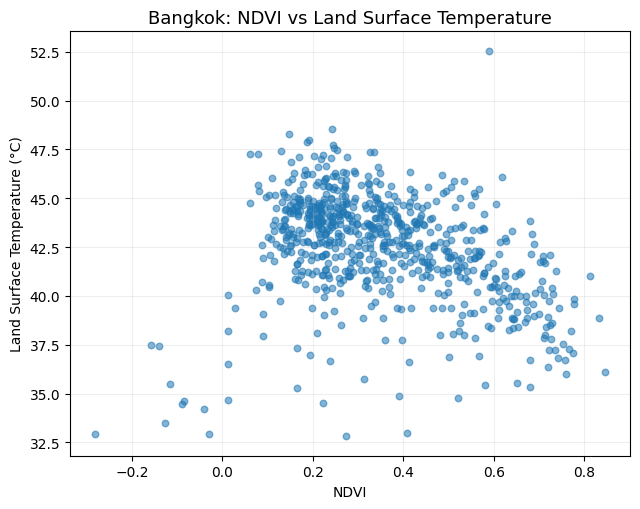

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.scatter(bkk_df["NDVI"], bkk_df["LST_C"], s=22, alpha=0.55)
ax.set_xlabel("NDVI")
ax.set_ylabel("Land Surface Temperature (°C)")
ax.set_title("Bangkok: NDVI vs Land Surface Temperature", fontsize=13)
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

## 8. Correlation และ Simple Linear Regression

In [7]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

r, p = pearsonr(bkk_df["NDVI"], bkk_df["LST_C"])

X = bkk_df[["NDVI"]].values
y = bkk_df["LST_C"].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"Pearson r = {r:.3f}")
print(f"p-value   = {p:.4g}")
print(f"Intercept = {model.intercept_:.3f} °C")
print(f"Slope     = {model.coef_[0]:.3f} °C per NDVI unit")
print(f"R²        = {r2:.3f}")

Pearson r = -0.297
p-value   = 1.044e-15
Intercept = 44.013 °C
Slope     = -4.346 °C per NDVI unit
R²        = 0.088


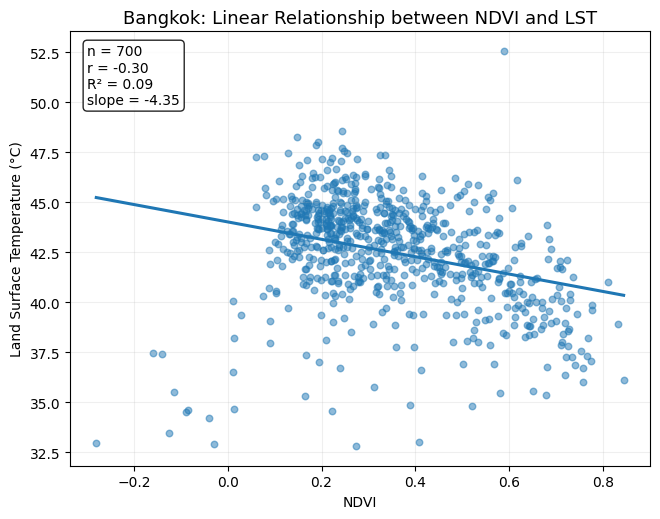

In [8]:
x_line = np.linspace(bkk_df["NDVI"].min(), bkk_df["NDVI"].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(6.7, 5.3))
ax.scatter(bkk_df["NDVI"], bkk_df["LST_C"], s=22, alpha=0.5)
ax.plot(x_line, y_line, linewidth=2.2)

ax.set_xlabel("NDVI")
ax.set_ylabel("Land Surface Temperature (°C)")
ax.set_title("Bangkok: Linear Relationship between NDVI and LST", fontsize=13)
ax.grid(True, alpha=0.2)

annotation = (
    f"n = {len(bkk_df)}\n"
    f"r = {r:.2f}\n"
    f"R² = {r2:.2f}\n"
    f"slope = {model.coef_[0]:.2f}"
)
ax.text(
    0.03, 0.97, annotation,
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

fig.tight_layout()
plt.show()

## 9. การตีความอย่างถูกต้อง

หาก slope เป็นลบ หมายความว่า:

> ใน sample นี้ NDVI ที่สูงขึ้น **สัมพันธ์** กับ LST ที่ต่ำลงโดยเฉลี่ย ภายใต้ linear model นี้

**อย่าเขียนว่า:** “NDVI ทำให้ LST ลดลง” โดยอัตโนมัติ

เพราะอาจมีตัวแปรร่วม เช่น:
- elevation
- moisture
- land-cover type
- urban morphology
- proximity to water
- topography
- spatial autocorrelation

## 10. แบบฝึกหัด — Chiang Mai

ให้ทำ:
1. สร้าง Landsat hot-season stack ของ Chiang Mai
2. แสดง NDVI และ LST map
3. สุ่ม 700 pixels
4. สร้าง scatterplot
5. คำนวณ Pearson r
6. fit simple linear regression
7. รายงาน slope และ $R^2$
8. เขียนข้อจำกัดอย่างน้อย 2 ข้อ

**คำถามอภิปราย:** เหตุใด topography อาจทำให้ Chiang Mai ซับซ้อนกว่า Bangkok?

In [9]:
# TODO:
# cm_ic, cm_stack = make_analysis_stack(cm_zone)
# samples_cm = cm_stack.sample(...)
# cm_df = ...
# scatterplot
# correlation
# LinearRegression

## 11. Optional Extension — Multiple Regression

สำหรับผู้เรียนที่เสร็จเร็ว สามารถขยายเป็น:

$$
LST = \beta_0 + \beta_1 NDVI + \beta_2 Built + \beta_3 Elevation + \epsilon
$$

แต่ **ไม่ใช่เนื้อหาบังคับ** ของคาบ 5 ชั่วโมง เพราะก่อนใช้ multiple regression ควรเข้าใจเรื่อง multicollinearity, spatial autocorrelation และ scale matching เพิ่มเติม

## 12. สิ่งที่ควรได้จาก Notebook 05

- แผนที่ใช้ค้นหา spatial pattern
- scatterplot ใช้ตรวจรูปแบบความสัมพันธ์
- regression ใช้ quantify association
- $R^2$ ไม่ใช่เครื่องรับรองว่า model “ถูกต้อง”
- correlation/regression ไม่พิสูจน์ causation
- spatial data มี dependence และ scale issues ที่ต้องระวัง

# SOLUTION — เปิดหลังทำแบบฝึกหัดแล้ว

n = 699
Pearson r = -0.749
p-value   = 8.986e-127
Intercept = 42.606 °C
Slope     = -15.468 °C per NDVI unit
R²        = 0.561


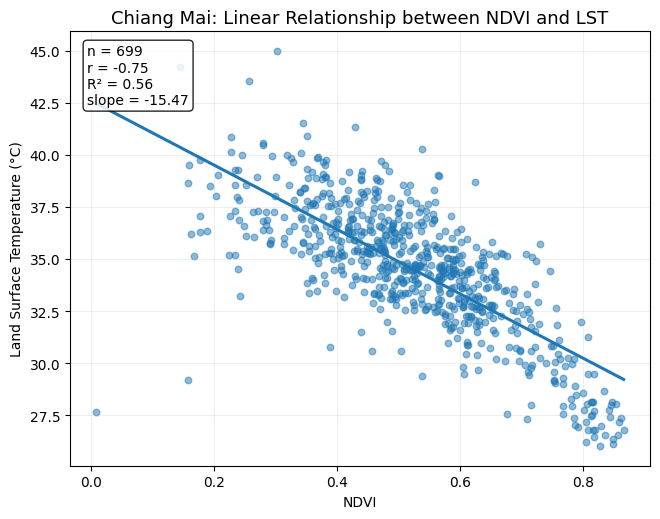

In [10]:
cm_ic, cm_stack = make_analysis_stack(cm_zone)

samples_cm = cm_stack.sample(
    region=cm_zone,
    scale=30,
    numPixels=700,
    seed=42,
    geometries=False,
    dropNulls=True,
)

sample_info_cm = samples_cm.getInfo()["features"]
cm_df = pd.DataFrame([f["properties"] for f in sample_info_cm])
cm_df = cm_df[["NDVI", "LST_C"]].dropna()

r_cm, p_cm = pearsonr(cm_df["NDVI"], cm_df["LST_C"])

X_cm = cm_df[["NDVI"]].values
y_cm = cm_df["LST_C"].values

model_cm = LinearRegression()
model_cm.fit(X_cm, y_cm)
pred_cm = model_cm.predict(X_cm)
r2_cm = r2_score(y_cm, pred_cm)

print(f"n = {len(cm_df)}")
print(f"Pearson r = {r_cm:.3f}")
print(f"p-value   = {p_cm:.4g}")
print(f"Intercept = {model_cm.intercept_:.3f} °C")
print(f"Slope     = {model_cm.coef_[0]:.3f} °C per NDVI unit")
print(f"R²        = {r2_cm:.3f}")

x_line_cm = np.linspace(cm_df["NDVI"].min(), cm_df["NDVI"].max(), 100)
y_line_cm = model_cm.predict(x_line_cm.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(6.7, 5.3))
ax.scatter(cm_df["NDVI"], cm_df["LST_C"], s=22, alpha=0.5)
ax.plot(x_line_cm, y_line_cm, linewidth=2.2)

ax.set_xlabel("NDVI")
ax.set_ylabel("Land Surface Temperature (°C)")
ax.set_title("Chiang Mai: Linear Relationship between NDVI and LST", fontsize=13)
ax.grid(True, alpha=0.2)

annotation = (
    f"n = {len(cm_df)}\n"
    f"r = {r_cm:.2f}\n"
    f"R² = {r2_cm:.2f}\n"
    f"slope = {model_cm.coef_[0]:.2f}"
)
ax.text(
    0.03, 0.97, annotation,
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

fig.tight_layout()
plt.show()

### แนวการอภิปราย
หากเชียงใหม่แสดงความสัมพันธ์ NDVI–LST ที่ต่างจาก Bangkok ไม่ควรอธิบายว่าเป็นผลของ “เมือง” เพียงอย่างเดียว เพราะ Chiang Mai มี elevation และ terrain gradient สูงกว่า จึงมี potential confounding มากกว่า

## แหล่งข้อมูลอ้างอิง
- Landsat 8 Level 2 Collection 2 Tier 1: https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2
- Scikit-learn LinearRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html